COT-6405.   
Project.  
Pedro Perez

The notebook contains the following sections:    
Import required libraries.  
Utility functions used to plot test results and generate arrays of random points.  
Implementation of the Brute Force and Divide and Conquer algorithms for the closest points problem.  
Testing of the algorithms.  
Experiments to analyze the running time.  
Save the average running times per algorithm and sample size to csv files.  

In [1]:
import math
import matplotlib.pyplot as plt
import random
import csv
import numpy as np
import time

Utility functions

In [2]:
# function to plot the points and the closest pair

def plot_points_and_closest_pair(P, index1, index2, title):
    x_coords = [p[0] for p in P]
    y_coords = [p[1] for p in P]
    
    plt.scatter(x_coords, y_coords, color='blue', label='Points')
    
    # Plot the closest pair
    plt.plot([P[index1][0], P[index2][0]], [P[index1][1], P[index2][1]], color='red', linewidth=2, label='Closest Pair')
    
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [3]:
# function to generate random points

def generate_random_points(num_points, x_range=(0, 100), y_range=(0, 100),seed=None):
    if seed is not None:
        random.seed(seed)
    noduplicate_points = set()

    points = []
    e = 0
    while e < num_points:
         x = random.randrange(*x_range)
         y = random.randrange(*y_range)
         # Ensure that duplicate points are not added
         if (x, y) not in noduplicate_points:
             noduplicate_points.add((x, y))
             e += 1
    points = list(noduplicate_points)

    return points

Functions implementing the algorithms

In [4]:

def BruteForceClosestPoint(P):
    # P is a list of n points, n ≥ 2, each point is a tuple (x, y)
    # Returns the 1-based indices of the closest pair of points

    n = len(P)
    print("Running Brute Force Algorithm on", n, "points...")
    d_min = float('inf')
    index1 = -1
    index2 = -1
    # the range(n) function starts at 0 and goes up to n-1,  using n-1 to exclude the last element in the first loop
    for i in range(n - 1):   # i will go from 0 to n-2 => n-1 elements
        # the range function is exclusive of the upper bound, using n to include the last element in the array in the second loop
        for j in range(i + 1, n):  # j will go from i+1 to n-1
            # Calculate Euclidean distance
            d = math.sqrt((P[i][0] - P[j][0])**2 + (P[i][1] - P[j][1])**2)
            if d < d_min:
                d_min = d
                index1 = i
                index2 = j
    print(f"Closest pair found at indices: {index1+1} and {index2+1} with distance: {d_min}")
    return index1+1, index2+1 # 1-based index

In [5]:
def DivideandConquerClosestPointRec(Px, Py):
    #print("Px:", Px)
    #print("Py:", Py)
    n = len(Px)
    #print("Number of points in this recursion:", n)
    # base case: use brute force for small number of points
    if n <= 3:
        d_min = float('inf')
        index1 = -1
        index2 = -1
        for i in range(n - 1):
            for j in range(i + 1, n):
                # Calculate Euclidean distance
                d = math.sqrt((P[Px[i]][0] - P[Px[j]][0])**2 + (P[Px[i]][1] - P[Px[j]][1])**2)
                if d < d_min:
                    d_min = d
                    index1 = Px[i]  # 0 based index for now
                    index2 = Px[j]  # 0 based index for now
        #print("Base case indices:", index1, index2)
        return index1, index2

    
    mid = math.ceil(n/2)
    #print("Mid index:", mid)
    
    # Divide points into two halves
    Qx = Px[:mid]  
    Rx = Px[mid:]
    
    # Maintain sorted order by y-coordinate for the halves
    Qy = [p for p in Py if p in Qx]
    Ry = [p for p in Py if p in Rx]
    #print("Qx:", Qx)
    #print("Rx:", Rx)
    #print("Qy:", Qy)
    #print("Ry:", Ry)
    
    # Recursively find closest pairs in both halves
    (left_pair_index1, left_pair_index2) = DivideandConquerClosestPointRec(Qx, Qy)
    (right_pair_index1, right_pair_index2) = DivideandConquerClosestPointRec(Rx, Ry)
    #print("Left pair indices:", left_pair_index1, left_pair_index2)
    #print("Right pair indices:", right_pair_index1, right_pair_index2)
    
    # Find the smaller distance between the two pairs
    d_left = math.sqrt((P[left_pair_index1][0] - P[left_pair_index2][0])**2 + 
                        (P[left_pair_index1][1] - P[left_pair_index2][1])**2)
    d_right = math.sqrt((P[right_pair_index1][0] - P[right_pair_index2][0])**2 + 
                        (P[right_pair_index1][1] - P[right_pair_index2][1])**2)
    d_min = min(d_left, d_right)

    xstar = P[Qx[-1]][0]  # The last point in Qx is the rightmost point in the left half

    # build line x = xstar
    L = xstar

    # Build S as the points in P that are within distance d_min of the line x = L
    S =  [p for p in Px if abs(P[p][0] - L) < d_min]
    Sy = [p for p in Py if abs(P[p][0] - L) < d_min]
    #print("Line x =", L)
    #print("Points in S:", S)
    #print("Points in Sy:", Sy)


    # Check Sy for closer pairs
    d_sy_min = d_min
    for i in range(len(Sy)):
        for j in range(i + 1, min(i + 15, len(Sy))):
            dx = P[Sy[i]][0] - P[Sy[j]][0]
            dy = P[Sy[i]][1] - P[Sy[j]][1]
            d_sy = math.sqrt(dx**2 + dy**2)
            if d_sy < d_sy_min:
                d_sy_min = d_sy
                sy_index1 = Sy[i]
                sy_index2 = Sy[j]

    if d_sy_min < d_min:
        return sy_index1, sy_index2
    elif d_left < d_right:
        return left_pair_index1, left_pair_index2
    else:
        return right_pair_index1, right_pair_index2



In [6]:
def DivideandConquerClosestPoint(P):

    # P is a list of n points, n ≥ 2, each point is a tuple (x, y)
    # Returns the 1-based indices of the closest pair of points
 
    n= len(P)
    print("Running Divide and Conquer Algorithm on", n, "points...")
    # Create a list of with the indices of the points
    Pindexed = [i for i in range(len(P))]    


    # Sort points by x-coordinate
    Px = sorted(Pindexed, key=lambda p: P[p][0])
    # Sort points by y-coordinate
    Py = sorted(Pindexed, key=lambda p: P[p][1])
    
    
    index1, index2 =  DivideandConquerClosestPointRec(Px, Py)
    print(f"Closest pair found at indices: {index1+1} and {index2+1} ")

    return index1+1, index2+1 # 1-based index

    

Sample testing.   
Test # 1   
Odd number of points

In [7]:
P=generate_random_points(11,(-20,20),(-20,20),seed=42)  # Generate 11 random points with a fixed seed for reproducibility
P

[(-14, 14),
 (-15, 17),
 (7, -18),
 (-19, -15),
 (-19, 15),
 (-6, -12),
 (-13, -19),
 (-7, -6),
 (-8, 14),
 (12, 18),
 (-3, -5)]

In [8]:
print("Testing Brute Force:")
index1, index2 = BruteForceClosestPoint(P)


Testing Brute Force:
Running Brute Force Algorithm on 11 points...
Closest pair found at indices: 1 and 2 with distance: 3.1622776601683795


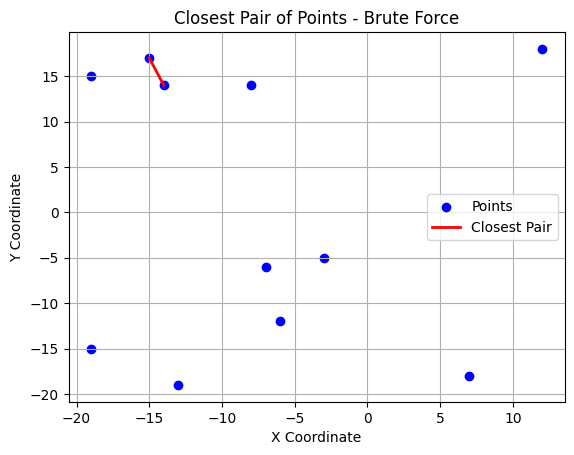

In [9]:
# use 0-indexing for plotting, but the functions return 1-indexing, so we need to subtract 1 from the indices
plot_points_and_closest_pair(P, index1-1, index2-1, "Closest Pair of Points - Brute Force")  # Example with the closest pair found by BruteForceClosestPoint

In [10]:
print("Testing Divide and Conquer:")
index1, index2 = DivideandConquerClosestPoint(P)


Testing Divide and Conquer:
Running Divide and Conquer Algorithm on 11 points...
Closest pair found at indices: 1 and 2 


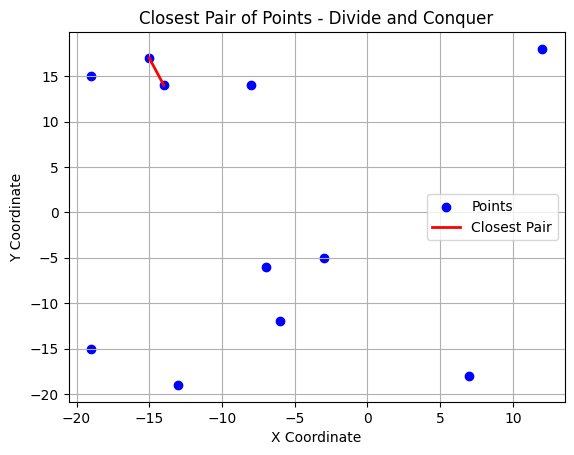

In [11]:
# use 0-indexing for plotting, but the functions return 1-indexing, so we need to subtract 1 from the indices
plot_points_and_closest_pair(P,index1-1, index2-1, "Closest Pair of Points - Divide and Conquer")  # Example with the closest pair found by DivideandConquerClosestPoint

Sample testing.   
Test # 2   
Even number of points

In [12]:
P=generate_random_points(12,(-20,20),(-20,20),seed=50)  # Generate 12 random points with a fixed seed for reproducibility
P

[(3, -5),
 (-11, 2),
 (-8, -16),
 (11, -3),
 (1, 18),
 (15, -15),
 (0, -6),
 (18, 7),
 (-15, -16),
 (10, 1),
 (-14, 2),
 (-15, 14)]

In [13]:
print("Testing Brute Force:")
index1, index2 = BruteForceClosestPoint(P)


Testing Brute Force:
Running Brute Force Algorithm on 12 points...
Closest pair found at indices: 2 and 11 with distance: 3.0


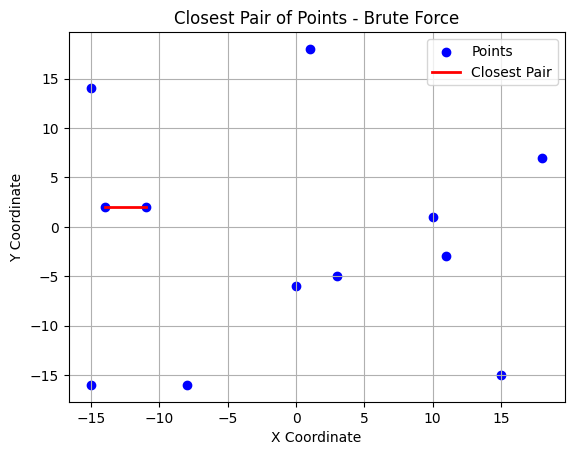

In [14]:
# use 0-indexing for plotting, but the functions return 1-indexing, so we need to subtract 1 from the indices
plot_points_and_closest_pair(P, index1-1, index2-1, "Closest Pair of Points - Brute Force")  # Example with the closest pair found by BruteForceClosestPoint

In [15]:
print("Testing Divide and Conquer:")
index1, index2 = DivideandConquerClosestPoint(P)


Testing Divide and Conquer:
Running Divide and Conquer Algorithm on 12 points...
Closest pair found at indices: 2 and 11 


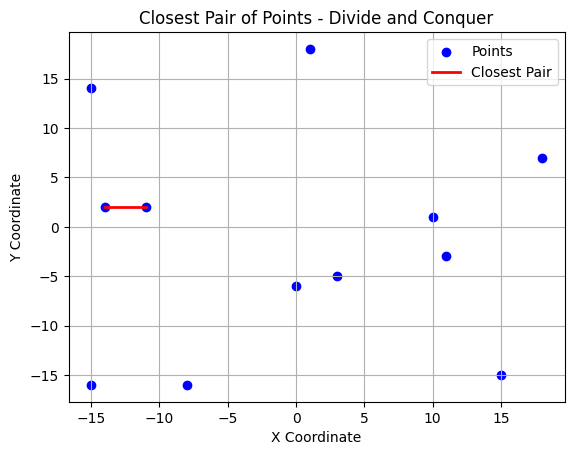

In [16]:
# use 0-indexing for plotting, but the functions return 1-indexing, so we need to subtract 1 from the indices
plot_points_and_closest_pair(P,index1-1, index2-1, "Closest Pair of Points - Divide and Conquer")  # Example with the closest pair found by DivideandConquerClosestPoint

Project experiments

In [17]:
# number of iterations
m = 10

In [18]:
# sample sizes to test
#sample_sizes = [i * 10**4 for i in range(1, 3)]  #
sample_sizes = [i * 10**4 for i in range(1, 11)]  # 10 sample sizes from 1*10**4 to 10*10**4
sample_sizes

[10000, 20000, 30000, 40000, 50000, 60000, 70000, 80000, 90000, 100000]

In [19]:
# seeds for reproducibility
# create a a matrix of seeds for each sample size and each iteration
np.random.seed(51)
seeds = np.random.randint(0, 1000, size=(len(sample_sizes), m))
seeds


array([[ 57, 485, 736, 969, 709, 528, 917, 734, 436, 361],
       [933, 634, 878, 549, 572, 862,  28, 852, 676, 163],
       [923, 998,  28, 426, 884, 906,   6, 793, 417, 461],
       [500, 935, 304,  24, 680,  54, 717, 884,  28, 837],
       [569, 786, 191,  75, 707, 252, 350, 471, 903, 765],
       [963, 219, 701, 760, 290, 437, 158,  55, 529, 707],
       [117, 621, 648, 441, 806, 141, 837,  87,  69, 241],
       [ 52, 641,  49,   3, 278, 667, 343, 866, 451, 509],
       [617, 641, 504, 318, 419, 919, 435,  95, 755, 477],
       [340, 788, 509, 794, 308, 637, 912, 174, 752, 995]])

In [20]:
# initialize matrices to store the average running times for each algorithm
bfavgtime= []
dcavgtime = []

In [21]:
for s in sample_sizes:
    bf_times_sum = 0
    dc_times_sum = 0
    print(f"Testing sample size: {s}")
    for i in range(m):
        print(f"Generating {s} random points for iteration:", i+1)
        P = generate_random_points(s, (-32000, 32000), (-32000, 32000), seed=int(seeds[sample_sizes.index(s)][i]))
        print("Random points generated. Running algorithms...")
        start_time = time.time()
        bf_index_1, bf_index_2 = BruteForceClosestPoint(P)
        end_time = time.time()
        print(f"Brute Force Algorithm completed in {end_time - start_time} seconds. ")
        bf_times_sum += end_time - start_time

        start_time = time.time()
        dc_index_1, dc_index_2 = DivideandConquerClosestPoint(P)
        end_time = time.time()
        print(f"Divide and Conquer Algorithm completed in {end_time - start_time} seconds. ")
        dc_times_sum += end_time - start_time

        #verify that both algorithms found the same closest pair
        if (bf_index_1, bf_index_2) != (dc_index_1, dc_index_2) and (bf_index_1, bf_index_2) != (dc_index_2, dc_index_1):
            #check if the distance between the pairs is the same, if they are the same then we can ignore the mismatch in indices
            bf_distance = math.sqrt((P[bf_index_1-1][0] - P[bf_index_2-1][0])**2 + (P[bf_index_1-1][1] - P[bf_index_2-1][1])**2)
            dc_distance = math.sqrt((P[dc_index_1-1][0] - P[dc_index_2-1][0])**2 + (P[dc_index_1-1][1] - P[dc_index_2-1][1])**2)
            if abs(bf_distance - dc_distance) < 1e-6:  # if the distances are the same, we can ignore the mismatch in indices
                print(f"Warning: Closest pair found by Brute Force ({bf_index_1}, {bf_index_2}) does not match closest pair found by Divide and Conquer ({dc_index_1}, {dc_index_2}), but the distances are the same. Ignoring index mismatch.")
                continue
            print(f"Error: Closest pair found by Brute Force ({bf_index_1}, {bf_index_2}) does not match closest pair found by Divide and Conquer ({dc_index_1}, {dc_index_2})")
            # raise an exception here to stop the program if the results do not match
            raise ValueError("Closest pairs do not match between algorithms.")

    bfavgtime.append(bf_times_sum / m)
    dcavgtime.append(dc_times_sum / m)

Testing sample size: 10000
Generating 10000 random points for iteration: 1
Random points generated. Running algorithms...
Running Brute Force Algorithm on 10000 points...
Closest pair found at indices: 3450 and 8582 with distance: 2.8284271247461903
Brute Force Algorithm completed in 15.79231309890747 seconds. 
Running Divide and Conquer Algorithm on 10000 points...
Closest pair found at indices: 3450 and 8582 
Divide and Conquer Algorithm completed in 1.6405560970306396 seconds. 
Generating 10000 random points for iteration: 2
Random points generated. Running algorithms...
Running Brute Force Algorithm on 10000 points...
Closest pair found at indices: 3097 and 6931 with distance: 3.605551275463989
Brute Force Algorithm completed in 15.924427032470703 seconds. 
Running Divide and Conquer Algorithm on 10000 points...
Closest pair found at indices: 3097 and 6931 
Divide and Conquer Algorithm completed in 1.714890956878662 seconds. 
Generating 10000 random points for iteration: 3
Random p

Export averages (empirical RTs) to csv files

In [22]:
# save the results for the brute force algorithm to a csv file
# each row in the csv file will contain the average time for each sample size

with open('bftable.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    for row in bfavgtime:
        writer.writerow([row])

print("CSV file 'bftable.csv' created successfully.")

CSV file 'bftable.csv' created successfully.


In [23]:
# save the results for the divide and conquer algorithm to a csv file
# each row in the csv file will contain the average time for each sample size
with open('dctable.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    for row in dcavgtime:
        writer.writerow([row])


print("CSV file 'dctable.csv' created successfully.")

CSV file 'dctable.csv' created successfully.
